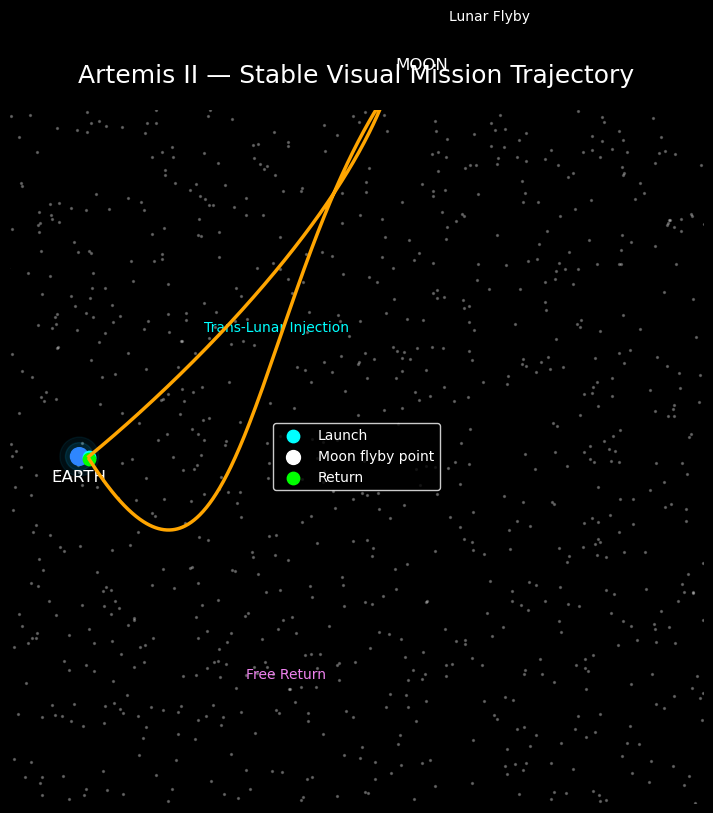

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

# =========================
# CONSTANTS (km)
# =========================
EARTH_RADIUS = 6371
MOON_RADIUS = 1737
MOON_DIST = 384400

# =========================
# FIGURE SETUP
# =========================
fig, ax = plt.subplots(figsize=(16, 9))
fig.patch.set_facecolor("black")
ax.set_facecolor("black")

# =========================
# STAR FIELD (stable + simple)
# =========================
np.random.seed(10)
ax.scatter(
    np.random.uniform(-80000, 480000, 1000),
    np.random.uniform(-250000, 250000, 1000),
    s=2,
    color="white",
    alpha=0.25
)

# =========================
# EARTH
# =========================
earth = np.array([0, 0])

ax.add_patch(Circle(earth, 14000, color="deepskyblue", alpha=0.08))
ax.add_patch(Circle(earth, 10000, color="deepskyblue", alpha=0.12))
ax.add_patch(Circle(earth, EARTH_RADIUS, color="#2E86FF"))

# =========================
# MOON (moved forward ~Artemis II timing)
# =========================
angle = np.deg2rad(50)
moon = np.array([
    MOON_DIST * np.cos(angle),
    MOON_DIST * np.sin(angle)
])

ax.add_patch(Circle(moon, 5000, color="white", alpha=0.08))
ax.add_patch(Circle(moon, MOON_RADIUS, color="lightgray"))

# =========================
# TRAJECTORY (ROBUST BEZIER CURVES)
# =========================
def bezier(p0, p1, p2, p3, n=400):
    t = np.linspace(0, 1, n)
    return (
        ((1 - t) ** 3)[:, None] * p0 +
        (3 * (1 - t) ** 2 * t)[:, None] * p1 +
        (3 * (1 - t) * t ** 2)[:, None] * p2 +
        (t ** 3)[:, None] * p3
    )

# Launch / TLI
p0 = np.array([EARTH_RADIUS + 500, 0])
p1 = np.array([80000, 60000])
p2 = np.array([200000, 180000])
p3 = moon + np.array([-20000, -15000])

outbound = bezier(p0, p1, p2, p3, 500)

# Lunar flyby arc (simple circle segment)
theta = np.linspace(2.3, 4.0, 200)
flyby_r = 12000
flyby = np.column_stack([
    moon[0] + flyby_r * np.cos(theta),
    moon[1] + flyby_r * np.sin(theta)
])

# Return leg
q0 = flyby[-1]
q1 = moon + np.array([-120000, -140000])
q2 = np.array([120000, -180000])
q3 = np.array([EARTH_RADIUS + 800, -2000])

return_leg = bezier(q0, q1, q2, q3, 600)

# Combine
traj = np.vstack([outbound, flyby, return_leg])

# =========================
# PLOT TRAJECTORY (SAFE)
# =========================
ax.plot(traj[:, 0], traj[:, 1],
        color="orange",
        linewidth=2.5,
        zorder=10)

# =========================
# KEY POINTS
# =========================
ax.scatter(p0[0], p0[1], color="cyan", s=80, label="Launch")
ax.scatter(moon[0], moon[1], color="white", s=100, label="Moon flyby point")
ax.scatter(q3[0], q3[1], color="lime", s=80, label="Return")

# =========================
# LABELS
# =========================
ax.text(0, -18000, "EARTH", color="white", ha="center", fontsize=12)
ax.text(moon[0], moon[1] - 15000, "MOON", color="white", ha="center", fontsize=12)

ax.text(90000, 90000, "Trans-Lunar Injection", color="cyan", fontsize=10)
ax.text(moon[0] + 20000, moon[1] + 20000, "Lunar Flyby", color="white", fontsize=10)
ax.text(120000, -160000, "Free Return", color="violet", fontsize=10)

# =========================
# FINAL STYLE
# =========================
ax.set_xlim(-50000, 450000)
ax.set_ylim(-250000, 250000)
ax.set_aspect("equal")

ax.set_xticks([])
ax.set_yticks([])

for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_title("Artemis II — Stable Visual Mission Trajectory",
             color="white",
             fontsize=18,
             pad=20)

ax.legend(facecolor="black", edgecolor="white")

plt.show()

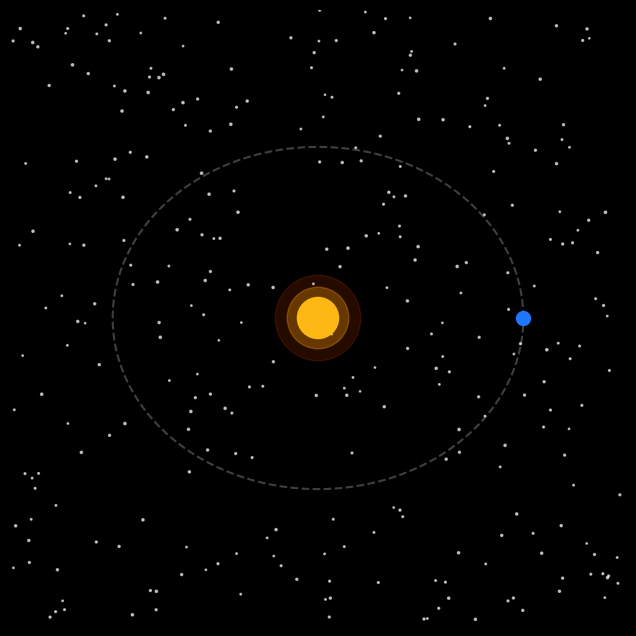

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# -----------------------------
# Figure setup (NASA-style dark space)
# -----------------------------
fig, ax = plt.subplots(figsize=(8, 8))
fig.patch.set_facecolor("black")
ax.set_facecolor("black")

ax.set_aspect('equal')
ax.set_xlim(-1.8, 1.8)
ax.set_ylim(-1.8, 1.8)
ax.axis("off")

# -----------------------------
# Starfield background
# -----------------------------
np.random.seed(42)
stars_x = np.random.uniform(-1.8, 1.8, 300)
stars_y = np.random.uniform(-1.8, 1.8, 300)
stars_size = np.random.uniform(1, 3, 300)

ax.scatter(stars_x, stars_y, s=stars_size, color="white", alpha=0.6)

# -----------------------------
# Sun (with glow effect)
# -----------------------------
sun_core = plt.Circle((0, 0), 0.12, color="#FDB813", zorder=5)
sun_glow1 = plt.Circle((0, 0), 0.18, color="#FFA500", alpha=0.3, zorder=4)
sun_glow2 = plt.Circle((0, 0), 0.25, color="#FF4500", alpha=0.15, zorder=3)

ax.add_patch(sun_glow2)
ax.add_patch(sun_glow1)
ax.add_patch(sun_core)

# -----------------------------
# Orbit path (elliptical like NASA realism)
# -----------------------------
a = 1.2  # semi-major axis
b = 1.0  # semi-minor axis

theta = np.linspace(0, 2*np.pi, 400)
ax.plot(a*np.cos(theta), b*np.sin(theta),
        color="white", linestyle="dashed", alpha=0.25)

# -----------------------------
# Earth
# -----------------------------
earth, = ax.plot([], [], 'o', color="#1f77ff", markersize=10, zorder=6)

# Earth trail (NASA-style motion streak)
trail_x, trail_y = [], []
trail, = ax.plot([], [], color="#4da3ff", alpha=0.4, linewidth=1)

# -----------------------------
# Animation
# -----------------------------
def update(frame):
    angle = frame * 0.015

    x = a * np.cos(angle)
    y = b * np.sin(angle)

    earth.set_data([x], [y])

    # trail effect
    trail_x.append(x)
    trail_y.append(y)

    if len(trail_x) > 120:
        trail_x.pop(0)
        trail_y.pop(0)

    trail.set_data(trail_x, trail_y)

    return earth, trail

ani = FuncAnimation(fig, update, frames=800, interval=20, blit=True)

plt.show()

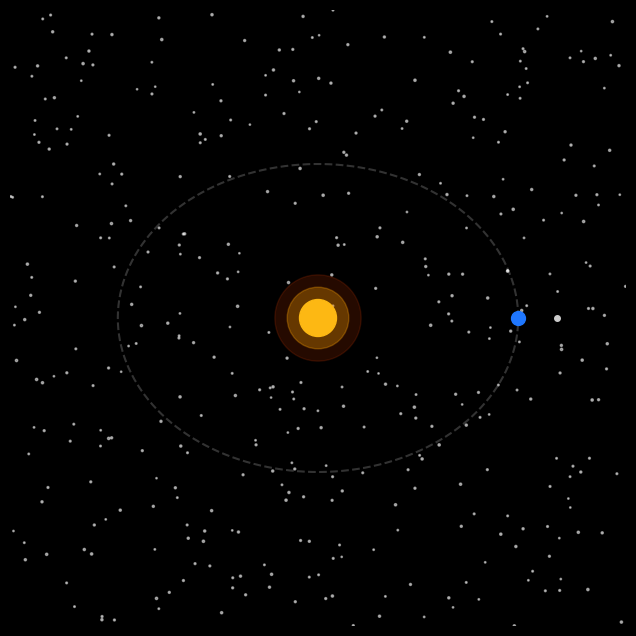

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# -----------------------------
# Figure setup (space look)
# -----------------------------
fig, ax = plt.subplots(figsize=(8, 8))
fig.patch.set_facecolor("black")
ax.set_facecolor("black")
ax.set_aspect('equal')
ax.set_xlim(-2, 2)
ax.set_ylim(-2, 2)
ax.axis("off")

# -----------------------------
# Stars background
# -----------------------------
np.random.seed(7)
ax.scatter(
    np.random.uniform(-2, 2, 400),
    np.random.uniform(-2, 2, 400),
    s=np.random.uniform(1, 3, 400),
    color="white",
    alpha=0.5
)

# -----------------------------
# Sun (glow effect)
# -----------------------------
ax.add_patch(plt.Circle((0, 0), 0.12, color="#FDB813", zorder=5))
ax.add_patch(plt.Circle((0, 0), 0.20, color="#FFA500", alpha=0.3, zorder=4))
ax.add_patch(plt.Circle((0, 0), 0.28, color="#FF4500", alpha=0.15, zorder=3))

# -----------------------------
# Orbit paths
# -----------------------------
a_earth, b_earth = 1.3, 1.0

theta = np.linspace(0, 2*np.pi, 500)
ax.plot(a_earth*np.cos(theta), b_earth*np.sin(theta),
        color="white", linestyle="dashed", alpha=0.2)

# -----------------------------
# Earth + Moon objects
# -----------------------------
earth, = ax.plot([], [], 'o', color="#1f77ff", markersize=10, zorder=6)
moon, = ax.plot([], [], 'o', color="#cccccc", markersize=4, zorder=7)

earth_trail, = ax.plot([], [], color="#4da3ff", alpha=0.4)
moon_trail, = ax.plot([], [], color="lightgray", alpha=0.4)

earth_x, earth_y = [], []
moon_x, moon_y = [], []

# -----------------------------
# Animation parameters
# -----------------------------
earth_speed = 0.015
moon_speed = 0.08
moon_orbit_radius = 0.25

# -----------------------------
# Animation function
# -----------------------------
def update(frame):
    # Earth orbit around Sun
    t = frame * earth_speed
    ex = a_earth * np.cos(t)
    ey = b_earth * np.sin(t)

    earth.set_data([ex], [ey])

    earth_x.append(ex)
    earth_y.append(ey)

    # Moon orbit around Earth
    mt = frame * moon_speed
    mx = ex + moon_orbit_radius * np.cos(mt)
    my = ey + moon_orbit_radius * np.sin(mt)

    moon.set_data([mx], [my])

    moon_x.append(mx)
    moon_y.append(my)

    # Keep trails short
    if len(earth_x) > 150:
        earth_x.pop(0); earth_y.pop(0)
    if len(moon_x) > 150:
        moon_x.pop(0); moon_y.pop(0)

    earth_trail.set_data(earth_x, earth_y)
    moon_trail.set_data(moon_x, moon_y)

    return earth, moon, earth_trail, moon_trail

ani = FuncAnimation(fig, update, frames=1000, interval=20, blit=True)

plt.show()

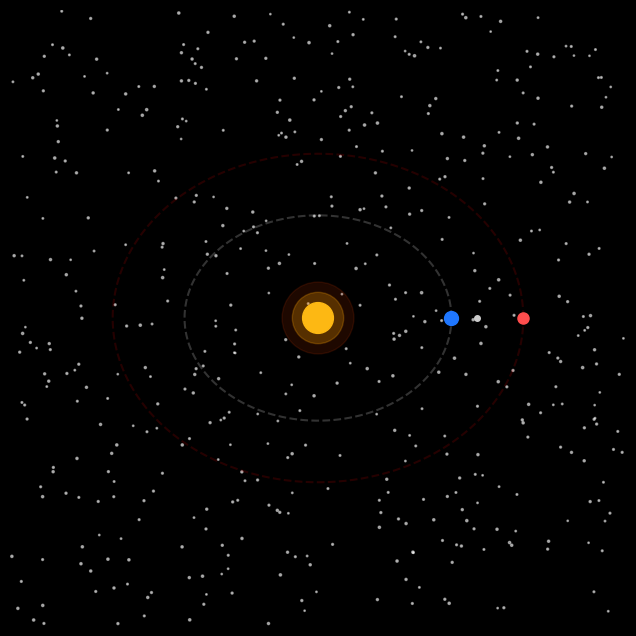

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# -----------------------------
# Figure setup (space)
# -----------------------------
fig, ax = plt.subplots(figsize=(8, 8))
fig.patch.set_facecolor("black")
ax.set_facecolor("black")
ax.set_aspect('equal')
ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
ax.axis("off")

# -----------------------------
# Stars background
# -----------------------------
np.random.seed(11)
ax.scatter(
    np.random.uniform(-3, 3, 500),
    np.random.uniform(-3, 3, 500),
    s=np.random.uniform(1, 3, 500),
    color="white",
    alpha=0.5
)

# -----------------------------
# Sun (glow)
# -----------------------------
ax.add_patch(plt.Circle((0, 0), 0.15, color="#FDB813", zorder=6))
ax.add_patch(plt.Circle((0, 0), 0.25, color="#FFA500", alpha=0.25, zorder=5))
ax.add_patch(plt.Circle((0, 0), 0.35, color="#FF4500", alpha=0.12, zorder=4))

# -----------------------------
# Orbit parameters
# -----------------------------
a_earth, b_earth = 1.3, 1.0
a_mars, b_mars = 2.0, 1.6   # Mars farther orbit

theta = np.linspace(0, 2*np.pi, 600)

# Orbit paths
ax.plot(a_earth*np.cos(theta), b_earth*np.sin(theta),
        color="white", linestyle="dashed", alpha=0.2)

ax.plot(a_mars*np.cos(theta), b_mars*np.sin(theta),
        color="red", linestyle="dashed", alpha=0.15)

# -----------------------------
# Celestial bodies
# -----------------------------
earth, = ax.plot([], [], 'o', color="#1f77ff", markersize=10)
moon,  = ax.plot([], [], 'o', color="#cccccc", markersize=4)
mars,  = ax.plot([], [], 'o', color="#ff4d4d", markersize=8)

# Trails
earth_trail, = ax.plot([], [], color="#4da3ff", alpha=0.4)
moon_trail,  = ax.plot([], [], color="lightgray", alpha=0.4)
mars_trail,  = ax.plot([], [], color="#ff9999", alpha=0.3)

earth_x, earth_y = [], []
moon_x, moon_y = [], []
mars_x, mars_y = [], []

# -----------------------------
# Speeds
# -----------------------------
earth_speed = 0.015
moon_speed  = 0.08
mars_speed  = 0.008

moon_radius = 0.25

# -----------------------------
# Animation
# -----------------------------
def update(frame):
    # Earth
    t = frame * earth_speed
    ex = a_earth * np.cos(t)
    ey = b_earth * np.sin(t)

    earth.set_data([ex], [ey])

    # Moon
    mt = frame * moon_speed
    mx = ex + moon_radius * np.cos(mt)
    my = ey + moon_radius * np.sin(mt)

    moon.set_data([mx], [my])

    # Mars
    mt2 = frame * mars_speed
    mars_x_pos = a_mars * np.cos(mt2)
    mars_y_pos = b_mars * np.sin(mt2)

    mars.set_data([mars_x_pos], [mars_y_pos])

    # Trails
    earth_x.append(ex); earth_y.append(ey)
    moon_x.append(mx); moon_y.append(my)
    mars_x.append(mars_x_pos); mars_y.append(mars_y_pos)

    max_len = 150
    if len(earth_x) > max_len:
        earth_x.pop(0); earth_y.pop(0)
        moon_x.pop(0); moon_y.pop(0)
        mars_x.pop(0); mars_y.pop(0)

    earth_trail.set_data(earth_x, earth_y)
    moon_trail.set_data(moon_x, moon_y)
    mars_trail.set_data(mars_x, mars_y)

    return earth, moon, mars, earth_trail, moon_trail, mars_trail

ani = FuncAnimation(fig, update, frames=1200, interval=20, blit=True)

plt.show()

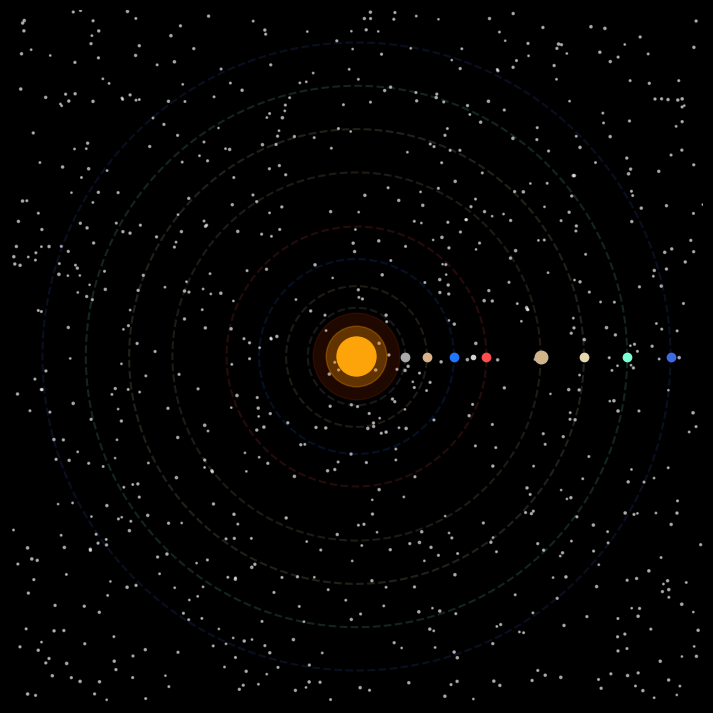